In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.append(os.path.abspath('..'))  # on est dans notebooks/

In [9]:
# Ajoute la racine du projet et importe les modules/fonctions utiles
import sys, os
from pathlib import Path


# import pratique - atm_tools
from src.cosmo_lidar.atm_tools import (
    effective_area_and_waist,
    alpha_specific_function,
    optical_depth_emission,
    contribution_effective_area,
    Calcul_T_ant_1_el,
    Calcul_T_sky_1_el,
    Calcul_T_ant_2,
    calcul_PWV,
    calcul_z_percentile_wvc,
    vapor_pressure,
    mass_quantile_grid,
    pwv_profile,
)

# import pratique - mc_tools
from src.cosmo_lidar.mc_tools import (
    generate_Pwater_MC,
    generate_Pwater_MC_lognormal,
    monte_carlo_t_ant,
    calcul_snr,
    remove_nans,
    Monte_Carlo_T_ant_mod,
    local_bin_width,
    scale_snr_for_variable_bins,
    predict_SNR_T,
    hybrid_lin_geom,
    Monte_Carlo_T_ant_profile,
)

# import pratique - io
from src.cosmo_lidar.io import (
    fetch_html,
    extract_ut_column_dat_links,
    download_some,
    read_radiosonde_dat,
    read_many_radiosonde,
    save_table,
    load_table,
    load_parquet_columns_as_numpy,
    to_float64,
)

import numpy as np
pi = np.pi
from scipy.interpolate import UnivariateSpline
from scipy.integrate import simpson
from scipy.integrate import trapezoid, cumulative_trapezoid
from matplotlib import pyplot as plt
import pandas as pd

In [3]:
import pycraf
from pycraf import conversions as cnv
from astropy import units as u

<>:138: SyntaxWarning: invalid escape sequence '\s'
<>:138: SyntaxWarning: invalid escape sequence '\s'
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_41287/134919863.py:138: SyntaxWarning: invalid escape sequence '\s'
  ax3.set_title(f"Bruit de Kolmogorov ($\sigma=${Turb_Int*100:.0f}%)")


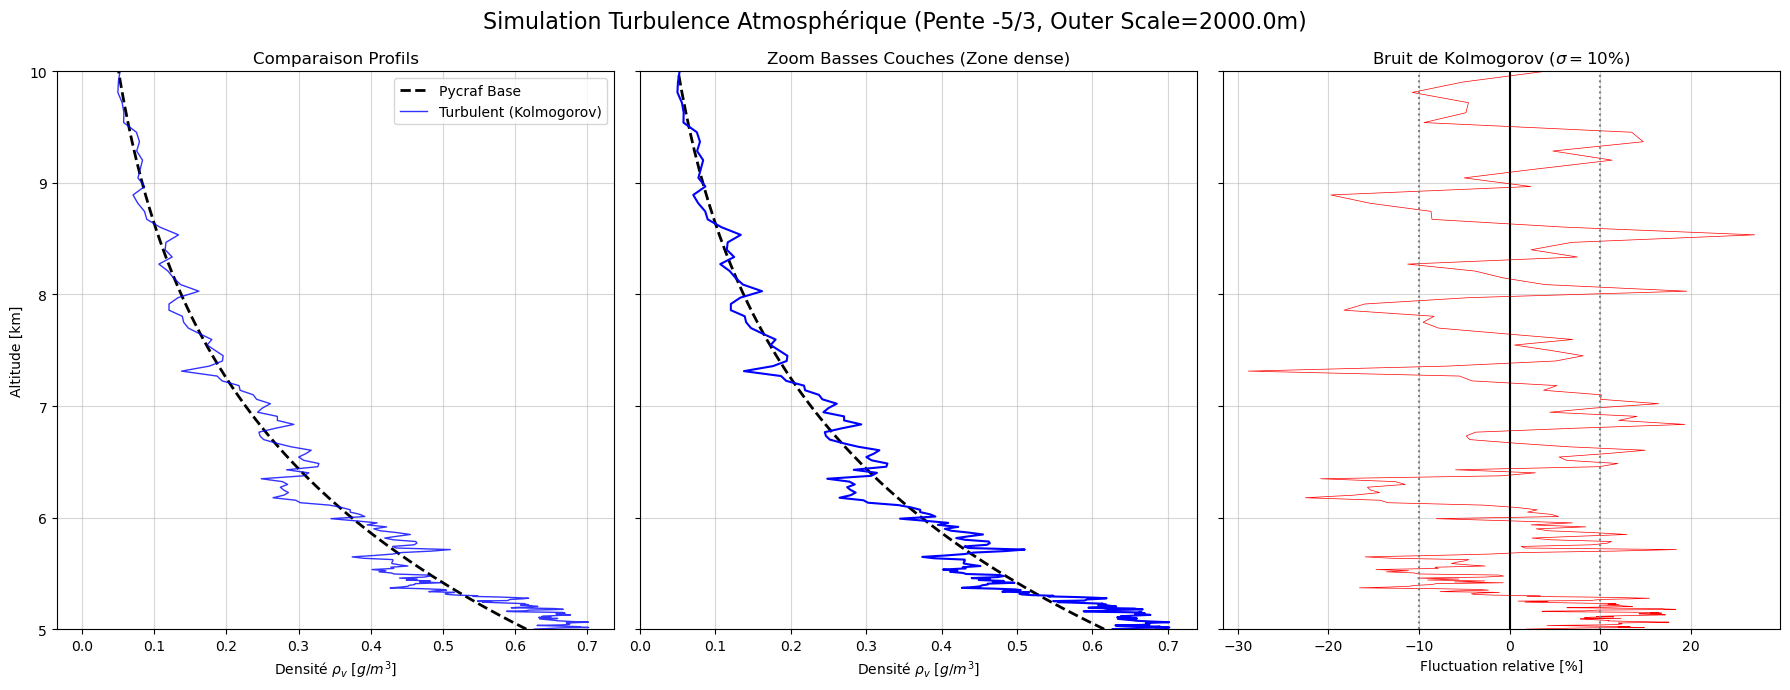

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pycraf
from astropy import units as u

# =============================================================================
# 1. GÉNÉRATION DU PROFIL DE BASE (PYCRAF)
# =============================================================================

# Paramètres physiques
R_water = 461.5  # J/(kg.K)

# Grille de simulation finale (Geomspace Atacama)
altitudes = np.geomspace(1, 15000, 500) + 4999
altitudes_km = (altitudes * u.m).to(u.km)

# Récupération du profil standard
profile = pycraf.atm.profile_standard(altitudes_km)
T_std = profile[0].value        # K
P_std = profile[1].value        # hPa
P_water_std = profile[3].value  # hPa

# Calcul de la densité de base (rho)
rho_base = (P_water_std * 100) / (R_water * T_std) * 1000 # g/m^3

# =============================================================================
# 2. GÉNÉRATION DE LA TURBULENCE (KOLMOGOROV)
# =============================================================================

def generate_kolmogorov_noise(z_min, z_max, n_points, outer_scale=1000.0, intensity=0.1):
    """
    Génère un bruit coloré 1D avec une pente -5/3 et une coupure basse fréquence.
    
    Paramètres :
    - outer_scale : Taille max des tourbillons (m). Au-delà, on coupe.
    - intensity : Ecart-type relatif de la fluctuation (ex: 0.1 = 10%)
    """
    # 1. Grille UNIFORME pour la FFT (indispensable)
    L = z_max - z_min
    dz = L / (n_points - 1)
    z_uniform = np.linspace(z_min, z_max, n_points)
    
    # 2. Bruit blanc initial
    white_noise = np.random.normal(0, 1, n_points)
    
    # 3. Passage en Fourier
    fft_noise = np.fft.fft(white_noise)
    freqs = np.fft.fftfreq(n_points, d=dz) # Nombres d'onde spatiaux (k)
    
    # 4. Construction du Filtre Spectral (Kolmogorov 1D)
    # Loi : E(k) ~ k^(-5/3)  => Amplitude ~ k^(-5/6) car E ~ Amp^2
    # On ajoute une petite valeur epsilon pour éviter division par 0
    k = np.abs(freqs)
    k[0] = 1e-9 # Gestion du DC
    
    spectral_filter = k ** (-5.0/6.0) 
    
    # 5. Coupure des Basses Fréquences (Outer Scale)
    # On supprime l'énergie pour les structures plus grandes que outer_scale
    k_cutoff = 1.0 / outer_scale
    
    # Filtre passe-haut (Hard cut ou Soft cut)
    # Ici Soft cut (Von Karman simplifié) : k / (k^2 + k0^2)^(5/12) est mieux, 
    # mais faisons un Hard Cut simple pour la visualisation :
    spectral_filter[k < k_cutoff] = 0 
    
    # 6. Application du filtre
    fft_filtered = fft_noise * spectral_filter
    
    # 7. Retour espace réel
    noise_filtered = np.fft.ifft(fft_filtered).real
    
    # 8. Normalisation
    # On force la moyenne à 0 et l'écart-type à 'intensity'
    noise_filtered = noise_filtered - np.mean(noise_filtered)
    current_std = np.std(noise_filtered)
    noise_normalized = noise_filtered / current_std * intensity
    
    return z_uniform, noise_normalized

# --- Paramètres de la turbulence ---
L_outer = 2000.0  # Taille max des structures verticales (ex: 2km max, stratification)
Turb_Int = 0.10   # 10% de fluctuation relative (assez fort pour voir)

# Génération sur une grille fine uniforme
z_uni, noise_uni = generate_kolmogorov_noise(
    z_min=altitudes[0], 
    z_max=altitudes[-1], 
    n_points=4096, # Puissance de 2 pour FFT rapide
    outer_scale=L_outer, 
    intensity=Turb_Int
)

# --- Interpolation sur la grille Geomspace ---
# On projette le bruit uniforme sur votre grille non-linéaire
noise_on_geom = np.interp(altitudes, z_uni, noise_uni)

# =============================================================================
# 3. APPLICATION AU PROFIL
# =============================================================================

# Modèle multiplicatif : rho_final = rho_base * (1 + bruit)
rho_turbulent = rho_base * (1 + noise_on_geom)

# Sécurité physique (pas de densité négative)
rho_turbulent = np.maximum(rho_turbulent, 0)

# =============================================================================
# 4. VISUALISATION
# =============================================================================

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

# Graphe 1 : Comparaison des profils
ax1.plot(rho_base, altitudes/1000, 'k--', linewidth=2, label="Pycraf Base")
ax1.plot(rho_turbulent, altitudes/1000, 'b-', linewidth=1, alpha=0.8, label="Turbulent (Kolmogorov)")
ax1.set_xlabel(r"Densité $\rho_v$ [$g/m^3$]")
ax1.set_ylabel("Altitude [km]")
ax1.set_title("Comparaison Profils")
ax1.legend()
ax1.grid(True, alpha=0.5)

# Graphe 2 : Zoom sur les basses couches (pour voir la texture)
ax2.plot(rho_base, altitudes/1000, 'k--', linewidth=2)
ax2.plot(rho_turbulent, altitudes/1000, 'b-', linewidth=1.5)
ax2.set_xlabel(r"Densité $\rho_v$ [$g/m^3$]")
ax2.set_title("Zoom Basses Couches (Zone dense)")
ax2.set_ylim(5, 10) # Zoom entre 5km et 10km
ax2.set_xlim(0, max(rho_base)*1.2)
ax2.grid(True, alpha=0.5)

# Graphe 3 : La perturbation seule (Relative)
ax3.plot(noise_on_geom * 100, altitudes/1000, 'r-', linewidth=0.5)
ax3.axvline(0, color='k', linestyle='-')
ax3.axvline(Turb_Int*100, color='gray', linestyle=':')
ax3.axvline(-Turb_Int*100, color='gray', linestyle=':')
ax3.set_xlabel("Fluctuation relative [%]")
ax3.set_title(f"Bruit de Kolmogorov ($\sigma=${Turb_Int*100:.0f}%)")
ax3.grid(True, alpha=0.5)

plt.suptitle(f"Simulation Turbulence Atmosphérique (Pente -5/3, Outer Scale={L_outer}m)", fontsize=16)
plt.tight_layout()
plt.show()

<>:76: SyntaxWarning: invalid escape sequence '\s'
<>:76: SyntaxWarning: invalid escape sequence '\s'
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_41287/2830631092.py:76: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Distribution des PWV simulés ($\sigma = {sigma_pwv:.4f}$ mm)")


ANALYSE DU PROFIL UNIQUE AFFICHÉ
PWV Base (Pycraf)      : 1.2306 mm
PWV Turbulent (Actuel) : 1.2405 mm
Delta PWV (Instantané) : +0.0099 mm
----------------------------------------

Calcul statistique sur 200 réalisations de turbulence...
RÉSULTATS STATISTIQUES (dPWV)
Pour une intensité locale de turbulence de 10% :
-> L'écart-type du PWV est de : 0.00889 mm
-> Cela représente une variation de 0.72% du PWV total.
----------------------------------------


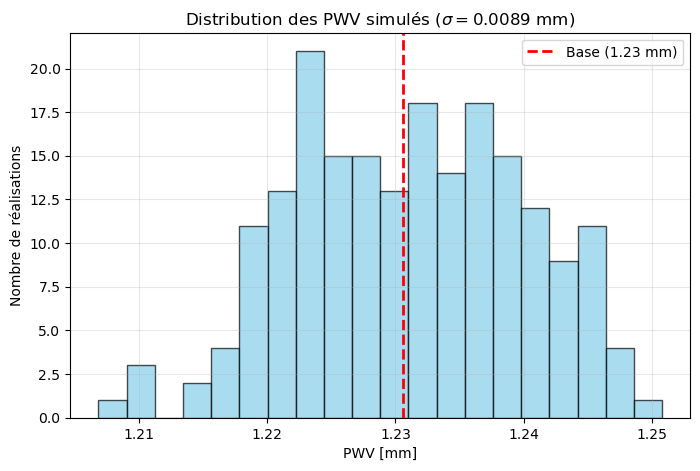

In [16]:
# ... (Suite du code précédent) ...
from scipy.integrate import trapezoid

# =============================================================================
# 5. CALCUL DU PWV DU PROFIL UNIQUE (Celui affiché)
# =============================================================================

# 1. PWV de base (Standard)
# Intégrale de rho(g/m3) * dz(m) = g/m2. Divisé par 1000 => kg/m2 (mm)
pwv_base = trapezoid(rho_base, altitudes) / 1000.0

# 2. PWV du profil turbulent généré
pwv_turb = trapezoid(rho_turbulent, altitudes) / 1000.0

# 3. Différence instantanée (dPWV pour ce tirage précis)
dpwv_inst = pwv_turb - pwv_base

print(f"{'='*40}")
print(f"ANALYSE DU PROFIL UNIQUE AFFICHÉ")
print(f"{'='*40}")
print(f"PWV Base (Pycraf)      : {pwv_base:.4f} mm")
print(f"PWV Turbulent (Actuel) : {pwv_turb:.4f} mm")
print(f"Delta PWV (Instantané) : {dpwv_inst:+.4f} mm")
print("-" * 40)


# =============================================================================
# 6. ESTIMATION STATISTIQUE DE LA PERTURBATION (dPWV = STD)
# =============================================================================
# On génère N réalisations pour voir quelle est la fluctuation typique (sigma_PWV)
# induite par vos paramètres de turbulence (Intensity=10%, Outer_Scale=2000m).

N_stats = 200
pwv_collection = []

print(f"\nCalcul statistique sur {N_stats} réalisations de turbulence...")

for _ in range(N_stats):
    # 1. Génération du bruit (Mêmes paramètres)
    _, noise_tmp = generate_kolmogorov_noise(
        z_min=altitudes[0], 
        z_max=altitudes[-1], 
        n_points=4096, 
        outer_scale=L_outer, 
        intensity=Turb_Int
    )
    
    # 2. Interpolation
    noise_interp = np.interp(altitudes, z_uni, noise_tmp)
    
    # 3. Application : rho = rho_base * (1 + bruit)
    rho_tmp = rho_base * (1 + noise_interp)
    rho_tmp = np.maximum(rho_tmp, 0) # Sécurité physique
    
    # 4. Calcul PWV
    val = trapezoid(rho_tmp, altitudes) / 1000.0
    pwv_collection.append(val)

# Calcul de l'écart-type
sigma_pwv = np.std(pwv_collection)

print(f"{'='*40}")
print(f"RÉSULTATS STATISTIQUES (dPWV)")
print(f"{'='*40}")
print(f"Pour une intensité locale de turbulence de {Turb_Int*100:.0f}% :")
print(f"-> L'écart-type du PWV est de : {sigma_pwv:.5f} mm")
print(f"-> Cela représente une variation de {sigma_pwv/pwv_base*100:.2f}% du PWV total.")
print("-" * 40)

# Petit histogramme pour vérifier la distribution
plt.figure(figsize=(8, 5))
plt.hist(pwv_collection, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(pwv_base, color='red', linestyle='--', linewidth=2, label=f'Base ({pwv_base:.2f} mm)')
plt.xlabel("PWV [mm]")
plt.ylabel("Nombre de réalisations")
plt.title(f"Distribution des PWV simulés ($\sigma = {sigma_pwv:.4f}$ mm)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

IMPACT RADIOMÉTRIQUE (1 Réalisation)
Fréquence       : 150 GHz
T_ant Référence : 10.1277 K
T_ant Perturbé  : 10.2117 K
-> Différence   : +0.0840 K
----------------------------------------
Calcul statistique sur 100 itérations...
STATISTIQUES DE FLUCTUATION
Pour Turb_Int=10.0% et L_outer=2000.0m :
Sigma PWV  : 0.0087 mm
Sigma T_ant: 0.0698 K
Ratio (pente locale) : 7.98 K/mm
----------------------------------------


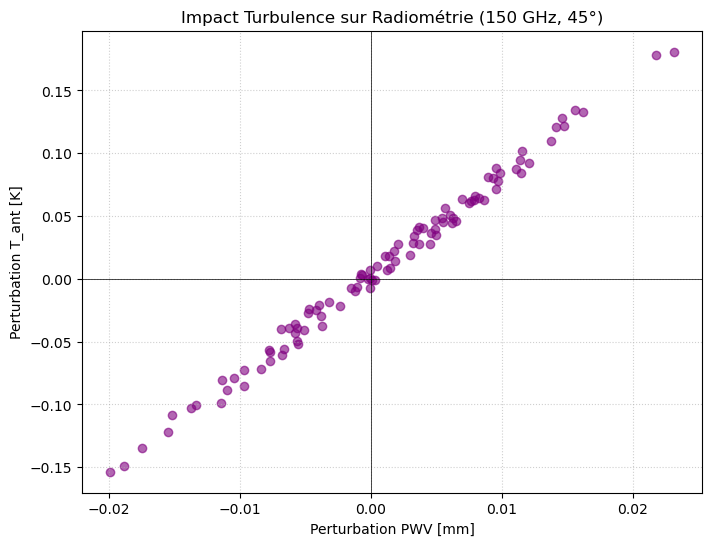

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pycraf
from astropy import units as u
from scipy.integrate import trapezoid

# On suppose que Calcul_T_sky_1_el, alpha_specific_function, etc. sont chargées
# Si besoin, assurez-vous qu'elles sont définies dans le notebook

# =============================================================================
# 1. PARAMÈTRES
# =============================================================================

frequency = np.array([150e9]) # 150 GHz
elevation = 45                # Degrés
R_water = 461.5               # J/(kg.K)

# Récupération des profils Pycraf (Base)
# altitudes, altitudes_km sont supposés définis comme avant
# T_std, P_std, P_water_std sont définis via pycraf.atm.profile_standard

# Calcul de rho_base (si pas déjà fait)
rho_base = (P_water_std * 100) / (R_water * T_std) * 1000 # g/m3

# =============================================================================
# 2. CONVERSION RHO -> PRESSION PARTIELLE
# =============================================================================

def rho_to_pressure(rho_g_m3, T_kelvin):
    """
    Inverse de la loi des gaz parfaits.
    rho [g/m3] -> P_water [hPa]
    """
    # P = rho * R * T
    # rho_kg = rho_g / 1000
    # P_pa = rho_kg * R * T
    # P_hpa = P_pa / 100
    
    P_hpa = (rho_g_m3 * R_water * T_kelvin) / (1000.0 * 100.0)
    return P_hpa

# =============================================================================
# 3. CALCUL UNIQUE (Une réalisation)
# =============================================================================

# 1. Génération de la perturbation (Reprise du code précédent)
# On suppose que 'noise_on_geom' est généré ou on le régénère ici
# (Assurez-vous d'avoir lancé la génération de turbulence avant)
# rho_turbulent = rho_base * (1 + noise_on_geom)

# 2. Conversion en Pression Partielle
P_water_turb = rho_to_pressure(rho_turbulent, T_std)

# 3. Calcul de T_ant pour la RÉFÉRENCE
T_ant_ref = Calcul_T_sky_1_el(
    frequency, altitudes, T_std, P_std, P_water_std, elevation
)[0]

# 4. Calcul de T_ant pour le PERTURBÉ
T_ant_turb = Calcul_T_sky_1_el(
    frequency, altitudes, T_std, P_std, P_water_turb, elevation
)[0]

# 5. Résultats
delta_T_ant = T_ant_turb - T_ant_ref

print(f"{'='*40}")
print(f"IMPACT RADIOMÉTRIQUE (1 Réalisation)")
print(f"{'='*40}")
print(f"Fréquence       : {frequency[0]/1e9:.0f} GHz")
print(f"T_ant Référence : {T_ant_ref:.4f} K")
print(f"T_ant Perturbé  : {T_ant_turb:.4f} K")
print(f"-> Différence   : {delta_T_ant:+.4f} K")
print("-" * 40)


# =============================================================================
# 4. ANALYSE STATISTIQUE (RMS)
# =============================================================================
# Une seule réalisation peut donner 0 par hasard.
# Calculons l'écart-type sur 100 tirages pour voir le "bruit" généré.

N_iter = 100
delta_T_collection = []
dpwv_collection = []

print(f"Calcul statistique sur {N_iter} itérations...")

for _ in range(N_iter):
    # A. Génération Bruit
    _, noise_tmp = generate_kolmogorov_noise(
        z_min=altitudes[0], z_max=altitudes[-1], n_points=4096, 
        outer_scale=L_outer, intensity=Turb_Int
    )
    noise_interp = np.interp(altitudes, z_uni, noise_tmp)
    
    # B. Profil Perturbé
    rho_loop = rho_base * (1 + noise_interp)
    rho_loop = np.maximum(rho_loop, 0)
    
    # C. Conversion Pression
    P_water_loop = rho_to_pressure(rho_loop, T_std)
    
    # D. Calcul T_ant
    val_T = Calcul_T_sky_1_el(frequency, altitudes, T_std, P_std, P_water_loop, elevation)[0]
    
    # E. Stockage
    delta_T_collection.append(val_T - T_ant_ref)
    
    # Calcul dPWV pour corrélation
    pwv_loop = trapezoid(rho_loop, altitudes) / 1000.0
    dpwv_collection.append(pwv_loop - pwv_base)

# Stats
sigma_tant = np.std(delta_T_collection)
sigma_pwv = np.std(dpwv_collection)

print(f"{'='*40}")
print(f"STATISTIQUES DE FLUCTUATION")
print(f"{'='*40}")
print(f"Pour Turb_Int={Turb_Int*100}% et L_outer={L_outer}m :")
print(f"Sigma PWV  : {sigma_pwv:.4f} mm")
print(f"Sigma T_ant: {sigma_tant:.4f} K")
print(f"Ratio (pente locale) : {sigma_tant/sigma_pwv:.2f} K/mm")
print("-" * 40)

# Visualisation Corrélation
plt.figure(figsize=(8, 6))
plt.scatter(dpwv_collection, delta_T_collection, alpha=0.6, color='purple')
plt.xlabel("Perturbation PWV [mm]")
plt.ylabel("Perturbation T_ant [K]")
plt.title(f"Impact Turbulence sur Radiométrie (150 GHz, 45°)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
plt.show()

<>:160: SyntaxWarning: invalid escape sequence '\_'
<>:160: SyntaxWarning: invalid escape sequence '\_'
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_41287/347969687.py:160: SyntaxWarning: invalid escape sequence '\_'
  plt.title(f"Effet Radiométrique de la Texture Turbulente (150 GHz)\n($T_{{turbulent}} - T_{{lisse\_scalé}}$)")


Profil de base normalisé à PWV = 1.00 mm
Calcul statistique sur 100 itérations...
IMPACT DE LA STRUCTURE TURBULENTE (À MASSE ÉGALE)
Pour une turbulence de 10.0% :
Ecart moyen (Biais) : 0.00278 K
Ecart-type (Bruit de forme) : 0.01368 K
--------------------------------------------------
INTERPRÉTATION :
C'est l'erreur que l'on commet en modélisant l'atmosphère comme lisse
alors qu'elle est grumeleuse, même si on connait parfaitement le PWV.


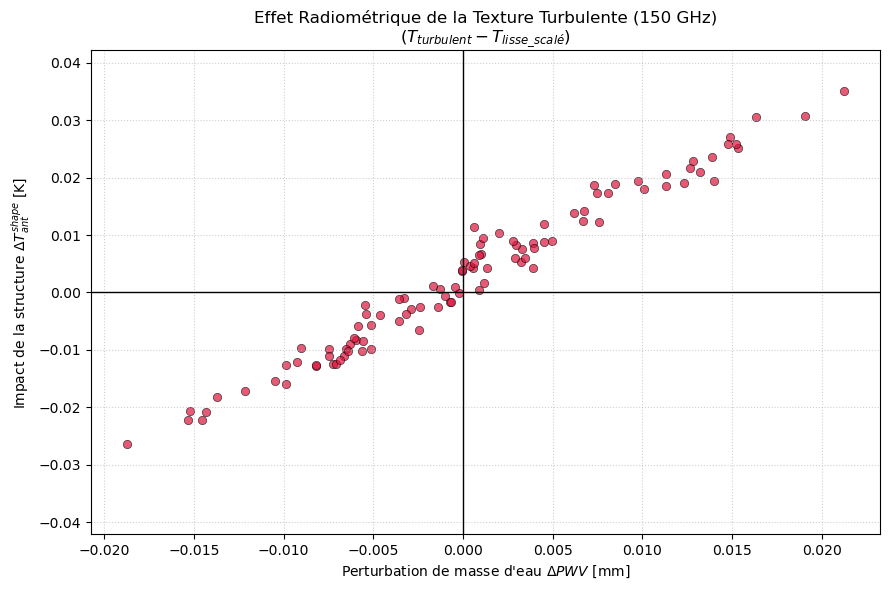

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pycraf
from astropy import units as u
from scipy.integrate import trapezoid

# =============================================================================
# 1. SETUP ET FONCTIONS UTILITAIRES
# =============================================================================

# Paramètres
frequency = np.array([150e9]) # 150 GHz
elevation = 45                # Degrés
R_water = 461.5               # J/(kg.K)
Turb_Int = 0.10               # Intensité turbulence (10%)
L_outer = 2000.0              # Échelle externe (m)

# Grille Verticale (Atacama)
altitudes = np.geomspace(1, 15000, 2000) + 4999 
altitudes_km = (altitudes * u.m).to(u.km)

# Profil Pycraf Standard
profile = pycraf.atm.profile_standard(altitudes_km)
T_std = profile[0].value        
P_std = profile[1].value        
P_water_raw = profile[3].value 

# --- Fonction Bruit Kolmogorov ---
def generate_kolmogorov_noise(z_min, z_max, n_points, outer_scale=1000.0, intensity=0.1):
    L = z_max - z_min
    z_uniform = np.linspace(z_min, z_max, n_points)
    
    # Bruit blanc -> Fourier
    white_noise = np.random.normal(0, 1, n_points)
    fft_noise = np.fft.fft(white_noise)
    freqs = np.fft.fftfreq(n_points, d=(L/(n_points-1)))
    
    # Filtre spectral k^(-5/3)
    k = np.abs(freqs)
    k[0] = 1e-9
    spectral_filter = k ** (-5.0/6.0) # Amplitude ~ sqrt(Energy)
    k_cutoff = 1.0 / outer_scale
    spectral_filter[k < k_cutoff] = 0 
    
    # Reconstruction
    noise_filtered = np.fft.ifft(fft_noise * spectral_filter).real
    noise_filtered = noise_filtered - np.mean(noise_filtered)
    noise_normalized = noise_filtered / np.std(noise_filtered) * intensity
    
    return z_uniform, noise_normalized

# --- Fonctions Physiques ---
def calc_rho_pwv(p_water_hpa, temp_k, z_m):
    """Retourne rho (g/m3) et PWV (mm)"""
    rho = (p_water_hpa * 100) / (R_water * temp_k) * 1000
    pwv = trapezoid(rho, x=z_m) / 1000.0
    return rho, pwv

def rho_to_pressure(rho_g_m3, T_kelvin):
    """rho [g/m3] -> P_water [hPa]"""
    return (rho_g_m3 * R_water * T_kelvin) / (1000.0 * 100.0)

# =============================================================================
# 2. NORMALISATION DU PROFIL DE BASE À 1.0 mm
# =============================================================================

# 1. Calcul du PWV brut Pycraf
_, pwv_pycraf_raw = calc_rho_pwv_zmoy(P_water_raw, T_std, altitudes) if 'calc_rho_pwv_zmoy' in locals() else calc_rho_pwv(P_water_raw, T_std, altitudes)

# 2. Scaling pour atteindre 1.0 mm exactement
scale_factor_1mm = 1.0 / pwv_pycraf_raw
P_water_base_1mm = P_water_raw * scale_factor_1mm

# 3. Calcul de la densité de base correspondante (rho_base)
rho_base_1mm, _ = calc_rho_pwv(P_water_base_1mm, T_std, altitudes)

print(f"Profil de base normalisé à PWV = 1.00 mm")

# =============================================================================
# 3. BOUCLE MONTE CARLO
# =============================================================================

N_iter = 100
delta_T_collection = [] # Ecart radiométrique (Turbulent - Lisse)
dpwv_collection = []    # Perturbation de masse d'eau (dPWV)

print(f"Calcul statistique sur {N_iter} itérations...")

for _ in range(N_iter):
    # --- A. Génération de la Turbulence ---
    z_uni, noise_tmp = generate_kolmogorov_noise(
        z_min=altitudes[0], z_max=altitudes[-1], n_points=4096, 
        outer_scale=L_outer, intensity=Turb_Int
    )
    noise_interp = np.interp(altitudes, z_uni, noise_tmp)
    
    # --- B. Profil Perturbé (Turbulent) ---
    rho_turb = rho_base_1mm * (1 + noise_interp)
    rho_turb = np.maximum(rho_turb, 0) # Physique
    
    # Calcul du PWV de ce profil turbulent
    # (Il ne sera pas exactement 1.0mm car le bruit a une moyenne locale non nulle une fois pondéré par rho)
    pwv_turb_val = trapezoid(rho_turb, x=altitudes) / 1000.0
    
    # Pression partielle correspondante
    P_water_turb = rho_to_pressure(rho_turb, T_std)
    
    # --- C. Profil de Référence Dynamique (Lisse) ---
    # On crée un profil qui a EXACTEMENT le même PWV que le turbulent, 
    # mais en gardant la forme lisse standard.
    # Facteur = PWV_turbulent / 1.0
    scale_dynamic = pwv_turb_val / 1.0
    P_water_ref_dynamic = P_water_base_1mm * scale_dynamic
    
    # --- D. Calculs Radiométriques ---
    
    # 1. T_ant du profil Turbulent
    T_ant_turb = Calcul_T_sky_1_el(
        frequency, altitudes, T_std, P_std, P_water_turb, elevation
    )[0]
    
    # 2. T_ant du profil Lisse (même masse d'eau)
    T_ant_ref_dyn = Calcul_T_sky_1_el(
        frequency, altitudes, T_std, P_std, P_water_ref_dynamic, elevation
    )[0]
    
    # --- E. Stockage ---
    # Différence : Effet pur de la structure (texture)
    delta_T_collection.append(T_ant_turb - T_ant_ref_dyn)
    
    # On stocke aussi le dPWV (PWV_turb - 1.0) pour l'axe X
    dpwv_collection.append(pwv_turb_val - 1.0)

# =============================================================================
# 4. ANALYSE ET VISUALISATION
# =============================================================================

# Stats
sigma_shape_effect = np.std(delta_T_collection)
mean_shape_effect = np.mean(delta_T_collection)

print(f"{'='*50}")
print(f"IMPACT DE LA STRUCTURE TURBULENTE (À MASSE ÉGALE)")
print(f"{'='*50}")
print(f"Pour une turbulence de {Turb_Int*100}% :")
print(f"Ecart moyen (Biais) : {mean_shape_effect:.5f} K")
print(f"Ecart-type (Bruit de forme) : {sigma_shape_effect:.5f} K")
print("-" * 50)
print("INTERPRÉTATION :")
print("C'est l'erreur que l'on commet en modélisant l'atmosphère comme lisse")
print("alors qu'elle est grumeleuse, même si on connait parfaitement le PWV.")

# Visualisation
plt.figure(figsize=(9, 6))

plt.scatter(dpwv_collection, delta_T_collection, alpha=0.7, color='crimson', edgecolors='k', linewidth=0.5)

plt.xlabel(r"Perturbation de masse d'eau $\Delta PWV$ [mm]")
plt.ylabel(r"Impact de la structure $\Delta T_{ant}^{shape}$ [K]")
plt.title(f"Effet Radiométrique de la Texture Turbulente (150 GHz)\n($T_{{turbulent}} - T_{{lisse\_scalé}}$)")

plt.grid(True, linestyle=':', alpha=0.6)
plt.axhline(0, color='k', linewidth=1)
plt.axvline(0, color='k', linewidth=1)

# On ajuste l'échelle Y pour bien voir les petites variations
# (Elles seront bien plus petites que dans le graphe précédent)
max_dev = np.max(np.abs(delta_T_collection))
if max_dev > 0:
    plt.ylim(-max_dev*1.2, max_dev*1.2)

plt.tight_layout()
plt.show()